In [ ]:
import tensorflow
import keras
from tensorflow.keras.layers import Dense, Flatten, Dropout, LSTM
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential
import numpy as np
import pandas as pd
import yfinance as yf

In [ ]:
data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
data.columns = ["Close","High","Low","Open","Volume"]

/tmp/ipykernel_6810/969233847.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
x = data[["High","Low","Open","Volume"]]
y = data["Close"]

In [ ]:
data["returns"] = (data["Close"] - data["Close"].shift(1)) / data["Close"].shift(1)
data["twentyday_sma"] = data["returns"].rolling(20).mean()

In [ ]:
data = data.drop(data.index[:20])

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
scaled_data = mms.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data)

In [ ]:
scaled_data.info()
scaled_data.head()
print(len(scaled_data))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2496 non-null   float64
 1   1       2496 non-null   float64
 2   2       2496 non-null   float64
 3   3       2496 non-null   float64
 4   4       2496 non-null   float64
 5   5       2496 non-null   float64
 6   6       2496 non-null   float64
dtypes: float64(7)
memory usage: 136.6 KB
2496


In [ ]:
prev_len = 180
pred_len = 30

x = []
y = []

for i in range(prev_len, (len(scaled_data) - pred_len)):
  x.append(scaled_data.iloc[i-prev_len:i].values)
  y.append(scaled_data.iloc[i:i+pred_len, 0].values)

x = np.array(x)
y = np.array(y)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=5)

In [ ]:
"""
initial_learningrate = 0.01
batch_size = 64
epochs = 30
def learningrateschedule(epochs,learning_rate):
  if epochs > 0 and epochs % 3 == 0:
    return learning_rate * 0.5
  else:
    return learning_rate
"""

'\ninitial_learningrate = 0.01\nbatch_size = 64\nepochs = 30\ndef learningrateschedule(epochs,learning_rate):\n  if epochs > 0 and epochs % 3 == 0:\n    return learning_rate * 0.5\n  else:\n    return learning_rate\n'

In [ ]:
neural_model = Sequential([
    LSTM(units=50, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dense(300, activation='relu'),
    Dropout(0.2),
    Dense(150, activation='relu'),
    Dropout(0.2),
    Dense(75, activation='relu'),
    Dropout(0.2),
    Dense(pred_len,activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#optimizer = SGD(learning_rate=initial_learningrate)
neural_model.compile(optimizer="Adam",loss="MAE")

In [ ]:
early_stopping = EarlyStopping(monitor="MAE",patience=3,restore_best_weights=True, mode='min')
#LR = LearningRateScheduler(learningrateschedule,verbose=1)

In [ ]:
history = neural_model.fit(x_train,y_train,epochs=50,batch_size=32, verbose=1)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.1317
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0496
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0399
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0362
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0348
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0333
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0314
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0319
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0305
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0302
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0298
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0301
Epoch 13/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0303
Epoch 14/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0294
Epoch 15/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0279
Epoc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


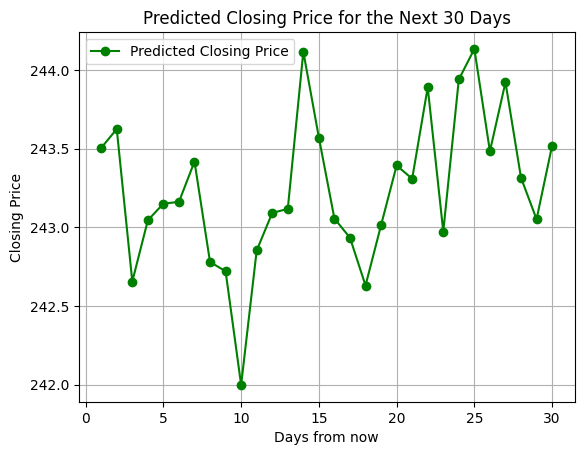

In [154]:
last_sequence = scaled_data.iloc[-prev_len:].values
last_sequence = last_sequence.reshape(1, prev_len, scaled_data.shape[1])

future_scaled_predictions = neural_model.predict(last_sequence)
future_scaled_predictions = future_scaled_predictions.flatten()

zeros = np.zeros((pred_len, scaled_data.shape[1]))
zeros[:, 0] = future_scaled_predictions

future_predictions = mms.inverse_transform(zeros)[:, 0]

days_to_predict = range(1, pred_len + 1)

plt.plot(days_to_predict, future_predictions, label='Predicted Closing Price', color='green', marker='o', linestyle='-')
plt.title('Predicted Closing Price for the Next 30 Days')
plt.xlabel('Days from now')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()